In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import csv

In [18]:
def openen(file_path: csv) -> list[dict]:
    """Opent een csv-bestand en maakt hier een lijst van.
    Gemaakt door Sven. """
    squirrel = []

    with open(file_path, 'r') as file:
        csv_reader = csv.DictReader(file)

        for row in csv_reader:
            squirrel.append(row)

    return squirrel

In [29]:
def maak_Digraph(squirrel: list[dict]) -> nx.DiGraph:
    """maakt een Digraph van de lijst
    gemaakt door Sven"""
    G = nx.DiGraph()

    for row in squirrel:
        source = row['id1']
        target = row['id2']

        G.add_edge(source, target)

    return G

In [ ]:
def pagerank(G: nx.DiGraph, d: float) -> dict:
    """Berekent de PageRank van alle nodes in een directed graph.
    Gemaakt door Sven"""

    N = G.number_of_nodes()
    pagerank = {}

    for node in G.nodes():
        pagerank[node] = 1 / N

    for _ in range(100):
        new_pagerank = {}

        for node in G.nodes():
            new_pagerank[node] = (1 - d) / N

            for other_node in G.predecessors(node):
                if G.out_degree(other_node) == 0:
                    contribution = pagerank[other_node] / N
                else:
                    contribution = pagerank[other_node] / G.out_degree(other_node)

                new_pagerank[node] += d*contribution

        pagerank = new_pagerank

    return pagerank

In [33]:
def maak_grafiek(pagerank: dict) -> None:
    """Maakt een histogram van de PageRank-probabilities.
    gemaakt door Sven"""

    plt.hist(pagerank.values(), bins=10, log=True)
    plt.xlabel("PageRank")
    plt.ylabel("Aantal nodes")
    plt.title("Verdeling van PageRank")
    plt.show()

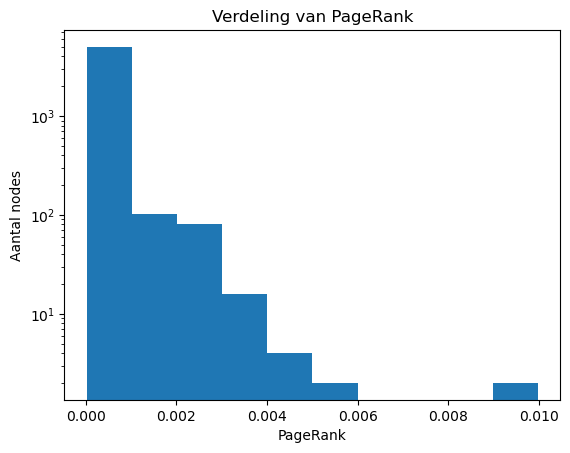

In [34]:
squirrel = openen("squirrel_edges.csv")
G = maak_Digraph(squirrel)
resultaat = pagerank(G, 0.85)
maak_grafiek(resultaat)